In [ ]:
import os
import sys
import random
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Seed
random.seed(42)
np.random.seed(42)

In [3]:
# Global variables
CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
DATA_PATH = os.path.join(CURRENT_DIR, 'data', 'tabular', 'real', 'parkinsons')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints', 'tabular', 'real', 'parkinsons')
OUT_PATH = os.path.join(CURRENT_DIR, 'out', 'tabular', 'real', 'parkinsons')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

# Show info on the terminal about how the execution is going.
VERBOSE = True
# Even if there is a checkpoint, the model is retrained.
FORCE_TRAINING = True
# Name of this experiment that will appear in the result files.
SUBFIX_NAME = 'gradient'

In [4]:
# fetch dataset
parkinsons_telemonitoring = fetch_ucirepo(id=189)

# data (as pandas dataframes)
df_data = parkinsons_telemonitoring.data.features
y = parkinsons_telemonitoring.data.targets

df_data = pd.concat([df_data, y], axis=1)

In [5]:
df_data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5875.0,64.804936,8.821524,36.000000,58.000000,65.000000,72.000000,85.000000
test_time,5875.0,92.863722,53.445602,-4.262500,46.847500,91.523000,138.445000,215.490000
Jitter(%),5875.0,0.006154,0.005624,0.000830,0.003580,0.004900,0.006800,0.099990
Jitter(Abs),5875.0,0.000044,0.000036,0.000002,0.000022,0.000034,0.000053,0.000446
Jitter:RAP,5875.0,0.002987,0.003124,0.000330,0.001580,0.002250,0.003290,0.057540
Jitter:PPQ5,5875.0,0.003277,0.003732,0.000430,0.001820,0.002490,0.003460,0.069560
Jitter:DDP,5875.0,0.008962,0.009371,0.000980,0.004730,0.006750,0.009870,0.172630
Shimmer,5875.0,0.034035,0.025835,0.003060,0.019120,0.027510,0.039750,0.268630
Shimmer(dB),5875.0,0.310960,0.230254,0.026000,0.175000,0.253000,0.365000,2.107000
Shimmer:APQ3,5875.0,0.017156,0.013237,0.001610,0.009280,0.013700,0.020575,0.162670


In [6]:
df_data.isna().sum()

age              0
test_time        0
Jitter(%)        0
Jitter(Abs)      0
Jitter:RAP       0
Jitter:PPQ5      0
Jitter:DDP       0
Shimmer          0
Shimmer(dB)      0
Shimmer:APQ3     0
Shimmer:APQ5     0
Shimmer:APQ11    0
Shimmer:DDA      0
NHR              0
HNR              0
RPDE             0
DFA              0
PPE              0
sex              0
motor_UPDRS      0
total_UPDRS      0
dtype: int64

In [7]:
df_data.nunique()

age                23
test_time        2442
Jitter(%)        1305
Jitter(Abs)      1326
Jitter:RAP        853
Jitter:PPQ5       840
Jitter:DDP       1703
Shimmer          3581
Shimmer(dB)       852
Shimmer:APQ3     2664
Shimmer:APQ5     2850
Shimmer:APQ11    3283
Shimmer:DDA      4223
NHR              5532
HNR              4780
RPDE             5430
DFA              5282
PPE              4777
sex                 2
motor_UPDRS      1080
total_UPDRS      1129
dtype: int64

<Axes: >

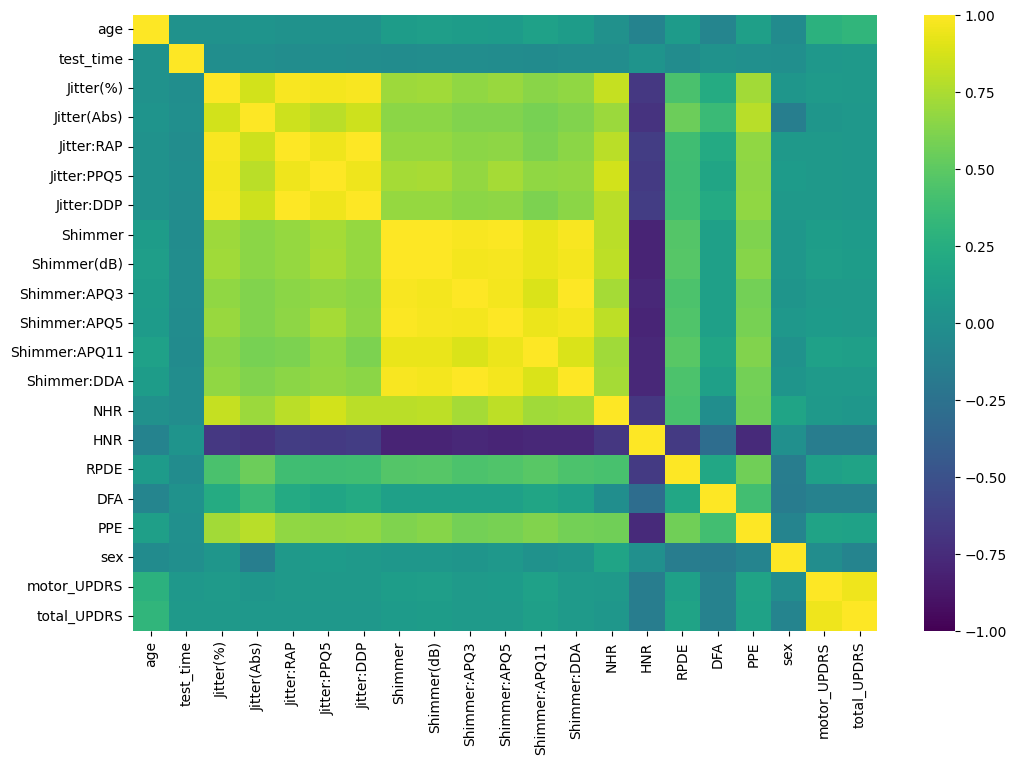

In [9]:
corr = df_data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="viridis", vmax=1, vmin=-1)

In [23]:
df_data.shape

(5875, 21)

In [25]:
df_data.to_parquet(
    os.path.join(
        DATA_PATH,
        'clean.parquet'
    )
)

# Getting rid of one of the twotarget variables as they are super correlated and it is easier to automate the execution process with just one

In [10]:
df_data = pd.read_parquet(
    os.path.join(
        DATA_PATH,
        'clean_old.parquet'
    )
)

df_data['y'] = df_data['total_UPDRS']
df_data.drop(columns=['total_UPDRS', 'motor_UPDRS'], inplace=True)

df_data.to_parquet(
    os.path.join(
        DATA_PATH,
        'clean.parquet'
    )
)